# Inlämningsuppgift: Del 2 - Adversarial input attack

Rasmus Johansson \
rajo22@student.bth.se

Rasmus Dunder \
radn21@student.bth.se

# Instruktioner

Ändra notebookens platshållare så som era namn- och mailuppgifter samt instruktioner i de olika avsnitten. 

Notebookens underrubriker på nivå 3 (###) är bara ett enkelt exempel på hur er implementation kan delas upp. Ni bör skapa egna rubriker anpassade efter er implementation men lämna alla nivå 1 (#) och 2-rubriker (##) som de är. En viktig del inom data-science är att kunna presentera sina metoder och resultat på ett tydligt sätt. **En ostrukturerad och otydlig notebook kan påverka betygsättningen.**

Notera att t.ex. hyperparameter-tuning och annan optimisering för prestanda inte är nödvändigt i denna uppgift. Så länge modellen fungerar märkvärt bättre än ett "coin flip" så räcker det att ni väljer era hyperparametrar manuellt.

# Uppgiften

Uppgiften går ut på att göra så att bilden på koalan nedan klassificeras som en traktor istället. Givetvis ska bilden på koalan se helt oförändrad ut för det mänskliga ögat då attacken är genomförd. Nedan följer Pythonkod som läser in de båda bilderna som uppgiften bygger på samt läser in en ResNet50-modell som klassiciferar bilderna. Saknar ni några Python-paket, t.ex. TensorFlow så installera dem med en pakethanterarare, t.ex. pip

## Beskrivning av adversarial input attacker

Börja med att förklara vad denna typ av attacker är och hur de fungerar i rapportens sektion 2.1.

## Nedan följer kod för att läsa in bilderna och klassificera dem med ResNet50 modellen

In [172]:
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import numpy as np
import json

import tensorflow as tf
import keras
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image

from art.estimators.classification import KerasClassifier
from art.attacks.evasion import BoundaryAttack
from art.utils import to_categorical

print("TF eager:", tf.executing_eagerly())
print("TF version:", tf.__version__)

print(f"TensorFlow: {tf.__version__}")


TF eager: True
TF version: 2.16.1
TensorFlow: 2.16.1


In [153]:
# Loads the pretrained ResNet50 model
model = ResNet50(weights='imagenet')

In [154]:
# Load the two images (koala & tractor)
init_image = image.load_img("images/koala.jpeg", target_size=(224, 224))
init_image = image.img_to_array(init_image)

target_image = image.load_img("images/tractor.jpeg", target_size=(224, 224))
target_image = image.img_to_array(target_image)

class_lookup = {105: "koala", 866: "tractor"}

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Init image class label: 105 (koala)


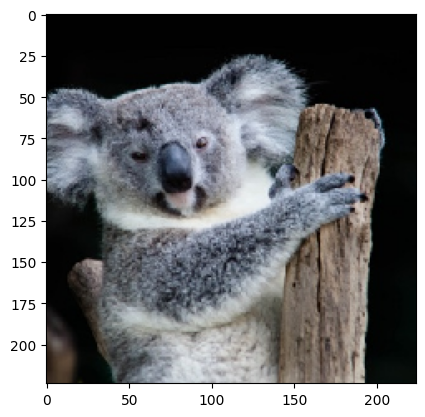

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Target image class label: 866 (tractor)


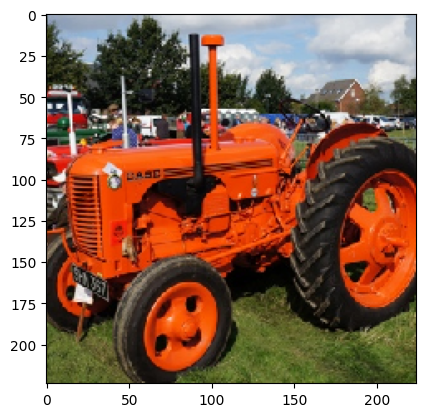

In [155]:
init_class_id = np.argmax(model.predict(np.array([init_image])))
print(f"Init image class label: {init_class_id} ({class_lookup[init_class_id]})")
plt.imshow(init_image.astype(np.uint))
plt.show()

target_class_id = np.argmax(model.predict(np.array([target_image])))
print(f"Target image class label: {target_class_id} ({class_lookup[target_class_id]})")
plt.imshow(target_image.astype(np.uint))
plt.show()

## Implementation av er attack

Beskriv i er rapport vad just er valda attack kallas och i detalj hur den fungerar (sektion 2.2 i rapporten). Beskriv även kort vilka bibliotek ni använder för att implementera den.

## Er kod för attacken

I cellerna nedan lägger ni in er egen kod för att genomföra attacken.

### Laddar in bibliotek och moduler


In [156]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.applications.resnet50 import decode_predictions, preprocess_input
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2


### Funktioner nödvändiga för attacken

In [157]:
def preprocess_image(image):
	# swap color channels, resize the input image, and add a batch
	# dimension
	image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
	image = cv2.resize(image, (224, 224))
	image = np.expand_dims(image, axis=0)
	# return the preprocessed image
	return image

def clip_eps(tensor, eps):
	# clip the values of the tensor to a given range and return it
	return tf.clip_by_value(tensor, clip_value_min=-eps,
		clip_value_max=eps)

def generate_targeted_adversaries(model, baseImage, delta, classIdx,
	target, steps=500):
	# iterate over the number of steps
	for step in range(0, steps):
		# record our gradients
		with tf.GradientTape() as tape:
			# explicitly indicate that our perturbation vector should
			# be tracked for gradient updates
			tape.watch(delta)
			# add our perturbation vector to the base image and
			# preprocess the resulting image
			adversary = preprocess_input(baseImage + delta)
			# run this newly constructed image tensor through our
			# model and calculate the loss with respect to the
			# both the *original* class label and the *target*
			# class label
			predictions = model(adversary, training=False)
			originalLoss = -sccLoss(tf.convert_to_tensor([classIdx]),
				predictions)
			targetLoss = sccLoss(tf.convert_to_tensor([target]),
				predictions)
			totalLoss = originalLoss + targetLoss
			# check to see if we are logging the loss value, and if
			# so, display it to our terminal
			if step % 20 == 0:
				print("step: {}, loss: {}...".format(step,
					totalLoss.numpy()))
		# calculate the gradients of loss with respect to the
		# perturbation vector
		gradients = tape.gradient(totalLoss, delta)
		# update the weights, clip the perturbation vector, and
		# update its value
		optimizer.apply_gradients([(gradients, delta)])
		delta.assign_add(clip_eps(delta, eps=EPS))
	# return the perturbation vector
	return delta

### Deklarerar variabler, laddar in bild och förbereder attack

In [158]:
EPS = 2 / 255.0
LR = 5e-3

image = cv2.imread("images/koala.jpeg")
image = preprocess_image(image)

optimizer = Adam(learning_rate=LR)
sccLoss = SparseCategoricalCrossentropy()

baseImage = tf.constant(image, dtype=tf.float32)
delta = tf.Variable(tf.zeros_like(baseImage), trainable=True)

### Genererar brus att lägga på bilden via modellering

In [159]:
deltaUpdated = generate_targeted_adversaries(model, baseImage, delta, 105, 866, 500)

step: 0, loss: 17.287296295166016...
step: 20, loss: 11.969427108764648...
step: 40, loss: 9.240342140197754...
step: 60, loss: 7.571726322174072...
step: 80, loss: 6.332394123077393...
step: 100, loss: 5.3775224685668945...
step: 120, loss: 4.586518287658691...
step: 140, loss: 3.87044095993042...
step: 160, loss: 3.2387008666992188...
step: 180, loss: 2.59553861618042...
step: 200, loss: 1.9424448013305664...
step: 220, loss: 1.359537124633789...
step: 240, loss: 0.8143043518066406...
step: 260, loss: 0.26963043212890625...
step: 280, loss: -0.3142557144165039...
step: 300, loss: -0.935490608215332...
step: 320, loss: -1.6142630577087402...
step: 340, loss: -2.394163131713867...
step: 360, loss: -3.158989906311035...
step: 380, loss: -3.95949649810791...
step: 400, loss: -4.893753528594971...
step: 420, loss: -6.036815643310547...
step: 440, loss: -7.367093086242676...
step: 460, loss: -8.863687515258789...
step: 480, loss: -10.996702194213867...


### Attack

Vi har innan detta steg genererat vilket brus vi ska lägga på bilden.
Detta genererades med Targeted FGSM som kördes i 500 i rundor för att få bilden att märkas som en traktor.

Vi lägger sedan ihop bilden med det genererade bruset och skickar in till modellen för att märkas.

In [160]:
adverImage = (baseImage + deltaUpdated).numpy().squeeze()
adverImage = np.clip(adverImage, 0, 255).astype("uint8")
adverImage = cv2.cvtColor(adverImage, cv2.COLOR_RGB2BGR)
cv2.imwrite("images/koala-attacked.jpeg", adverImage)

preprocessedImage = preprocess_input(baseImage + deltaUpdated)
predictions = model.predict(preprocessedImage)
predictions = decode_predictions(predictions, top=3)[0]
label = predictions[0][1]
confidence = predictions[0][2] * 100
print("[INFO] label: {} confidence: {:.2f}%".format(label,confidence))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[INFO] label: tractor confidence: 72.25%


### Attackresultat

Vi får att den nya bilden på koalan med det genererade bruset märker bilden som en traktor.
Nedan syns både bilden utan brus och bilden med brus som märks som en traktor. Jag ser ingen märkbar skillnad på bilderna förutom att den med brus möjlightvis är lite ljusare

(-0.5, 223.5, 223.5, -0.5)

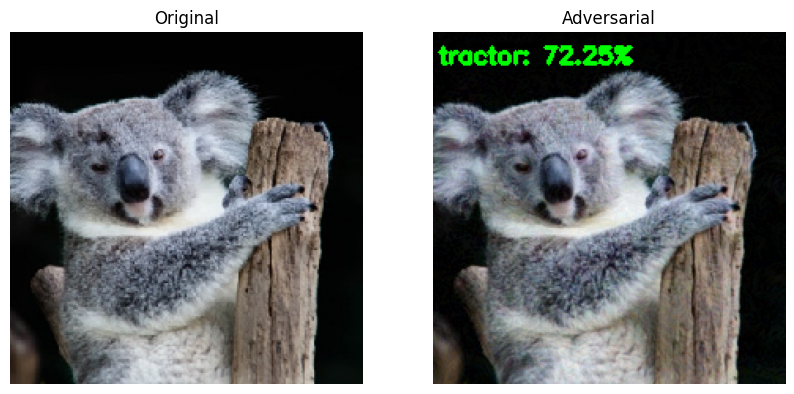

In [161]:
text = "{}: {:.2f}%".format(label, confidence)
cv2.putText(adverImage, text, (3, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
    (0, 255, 0), 2)
adver_rgb = cv2.cvtColor(adverImage, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.imshow(init_image.astype(np.uint))
plt.title("Original")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(adver_rgb)
plt.title("Adversarial")
plt.axis("off")

## Skyddsåtgärder

Beskriv (i rapportens sektion 2.3) vilka säkerhetsåtgärd(er) ni valt som lämpliga för att skydda mot er attack. Motivera varför ni valt just de(n) metod(erna).

## Implementation av skyddsåtgärder (frivilligt endast för A eller B)

Nedan fyller ni i er kod som implementerar skyddsmekanismen mot er attackmetod. Skriv även en summering av vad skyddsresultatet blev när ni implementerade metoden (beskriv detta i rapportens del 2.4).

### Egna funktioner

In [162]:
# Samla era egna funktioner relaterade till säkerhetsåtgärden här
# Funktionerna ska kort beskrivas med docstrings och kommentarer så att man förstår syftet och implementationen
# Blir det många bör ni bryta ut dessa i en separat fil


### Förberedelser

In [173]:
# E.g. skapande av ny modell, etc.

def smoothed_predict(model, img_uint8, sigma=10.0, samples=64, seed=None):
    rng = np.random.default_rng(seed)
    img = img_uint8.astype("float32")
    noises = rng.normal(0, sigma, size=(samples,) + img.shape).astype("float32")
    noisy_batch = np.clip(img + noises, 0, 255)
    x = preprocess_input(noisy_batch)
    preds = model.predict(x, verbose=0)
    preds_avg = preds.mean(axis=0, keepdims=True)
    decoded = decode_predictions(preds_avg, top=1)[0]
    return decoded



### Skydd

Beskriv säkerhetsåtgärden kortfattat här

In [164]:
# Implementation av skyddsåtgärd
prediction_results = {}
for i in range(0,31):
    smoothed_prediction = smoothed_predict(model, adverImage, sigma=float(i), samples=500, seed=123) # constant seed for easier testing
    smoothed_label = smoothed_prediction[0][1]
    smoothed_confidence = smoothed_prediction[0][2] * 100
    prediction_results[float(i)] = (smoothed_label, smoothed_confidence)

with open("prediction_results.json", "w") as f:
    json.dump(prediction_results, f, indent=4)


Smoothed prediction on adversarial:
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 290ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 336ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 285ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 286ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 285ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 286ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 281ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 329ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 283ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 281ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 290ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 283ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 284ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 327ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 282ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 283ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 282ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 280ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 280ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 290ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 287ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 288ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 279ms/step
16/16 ━━━━━━━━━━━━━━

/tmp/ipykernel_8450/2051256027.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", len(uniq))


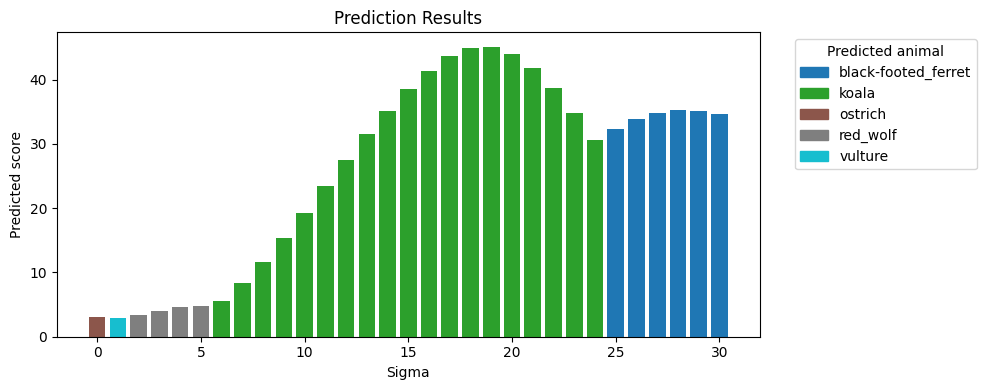

In [ ]:
def load_rows(path):
    data = json.load(open(path))
    if isinstance(data, list) and len(data) == 1 and isinstance(data[0], dict):
        data = data[0]  # unwrap the list in /tmp/res.json
    rows = []
    for k, v in data.items():
        if len(v) == 3:
            _, label, score = v      # e.g., ["n01882714", "koala", 0.38]
        else:
            label, score = v         # e.g., ["koala", 19.25]
        rows.append((float(k), label, float(score)))
    return sorted(rows, key=lambda r: r[0])

def plot_rows(rows, title):
    xs = [r[0] for r in rows]
    labels = [r[1] for r in rows]
    scores = [r[2] for r in rows]
    uniq = sorted(set(labels))
    cmap = cm.get_cmap("tab10", len(uniq))
    color_map = {lbl: cmap(i) for i, lbl in enumerate(uniq)}
    colors = [color_map[lbl] for lbl in labels]

    plt.figure(figsize=(10, 4))
    plt.bar(xs, scores, color=colors)
    plt.xlabel("Sigma")
    plt.ylabel("Predicted Score")
    plt.title(title)
    # legend
    handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[lbl]) for lbl in uniq]
    plt.legend(handles, uniq, title="Predicted animal", bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

rows_pred = load_rows("prediction_results.json")
plot_rows(rows_pred, "Prediction Results")

In [ ]:
# Final model
smoothed_prediction = smoothed_predict(model, adverImage, sigma=19, samples=500, seed=123)
smoothed_label = smoothed_prediction[0][1]
smoothed_confidence = smoothed_prediction[0][2] * 100
print("[INFO] label: {} confidence: {:.2f}%".format(smoothed_label,smoothed_confidence))

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 348ms/step
[INFO] label: koala confidence: 45.09%


### Skyddsresultat

Bevisa och förklara era skyddsresultat i flytande text här

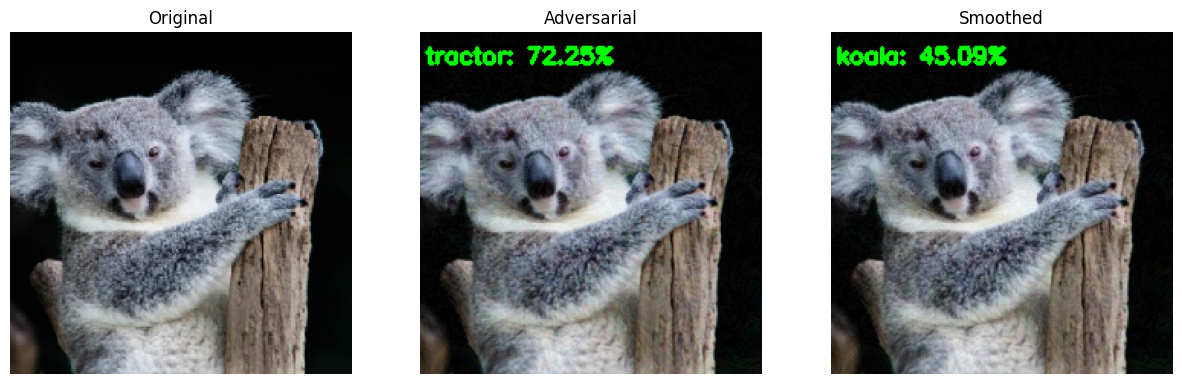

In [171]:
# Presentera skyddåtgärdens resultat m.h.a. kod här

smoothed_image = cv2.imread("images/koala-attacked.jpeg")

text_smoothed = "{}: {:.2f}%".format(smoothed_label, smoothed_confidence)
cv2.putText(smoothed_image, text_smoothed, (3, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

smoothed_rgb = cv2.cvtColor(smoothed_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,5))

# 1: Original
plt.subplot(1, 3, 1)
plt.imshow(init_image.astype(np.uint))
plt.title("Original")
plt.axis("off")

# 2: Adversarial
plt.subplot(1, 3, 2)
plt.imshow(adver_rgb)
plt.title("Adversarial")
plt.axis("off")

# 3: Smoothed (note: smoothed RGB is not a new image, so this only works if you created one)
plt.subplot(1, 3, 3)
plt.imshow(smoothed_rgb)
plt.title("Smoothed")
plt.axis("off")

plt.show()


# Referenser

https://pyimagesearch.com/2024/01/08/adversarial-learning-with-keras-and-tensorflow-part-1-overview-of-adversarial-learning/
https://pyimagesearch.com/2020/10/26/targeted-adversarial-attacks-with-keras-and-tensorflow/
